# Classificação do Uso e Cobertura da Terra com Multi-Layer Perceptron usando séries temporais variantes no tempo

## Carregando o _Dataset_

In [1]:
import json
import random
from datetime import datetime

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import requests
import seaborn
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from kfold import Kfold
from mlp_multiclass import FFNeuralNetwork, He_, Layer, Neuron, Xavier
from temporal_classification import (classify_temporal_series,
                                     plot_temporal,
                                     plot_real_trajectory,
                                     plot_temporal_classification)

from extraction_data_methods import *
from mlp_multiclass import *

def get_ts(sample):
    ts_ = json.loads(sample['time_series'])
    return pd.DataFrame(ts_)

def plot_ts(data_df, selected_line, marker=True, smoothed=False, step=5):
    ts = pd.DataFrame(json.loads(data_df['time_series'][selected_line]))
    fig = plt.figure(figsize=(10, 4))
    smoothed_ = ' Smoothed' if smoothed else ''
    fig.suptitle(
        ("{cube} {label} [{lng:,.4f}, {lat:,.4f}]{smoothed_} WGS 84 EPSG:4326").format(
            cube=data_df['cube'][selected_line],
            label=data_df['label'][selected_line],
            lng=data_df['longitude'][selected_line],
            lat=data_df['latitude'][selected_line],
            smoothed_=smoothed_
        )
    )
    seaborn.set_theme(style="darkgrid")
    bands = [band for band in list(ts.keys()) if band != 'Index']
    marker_ = 'o' if marker else None
    for band in bands:
        seaborn.lineplot(
            data=ts,
            x="Index",
            y=band,
            label=band,
            markersize=8,
            marker=marker_,
            linestyle='-'
        )
    ax = plt.gca()
    xticks = range(0, len(ts["Index"]), step)
    ax.set_xticks(xticks)
    ax.set_xticklabels(
        ts["Index"].iloc[::step]
    )
    plt.xlabel(None)
    plt.ylabel(None)
    plt.legend()
    plt.tight_layout()
    plt.show()

# get bands description
service = pystac_client.Client.open("https://data.inpe.br/bdc/stac/v1/")
collection = service.get_collection('mod13q1-6.1').to_dict()
bands_description = collection['properties']['eo:bands']

# Recuperando a base de dados
samples = pd.read_csv('./samples/samples_mt_time_series.csv')

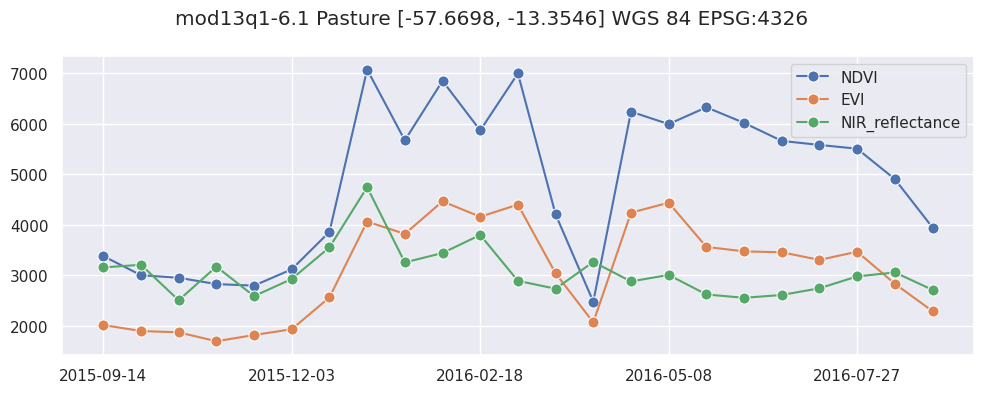

In [78]:
selection = random.randint(0, (len(samples) - 1))
plot_ts(samples, selection)

## Selecionando os atributos

In [3]:
bands = ["NDVI", "EVI", "NIR_reflectance"]
samples = extract_bands(samples, bands)

## Normalização dos valores à escala presente nos metadados do satélite

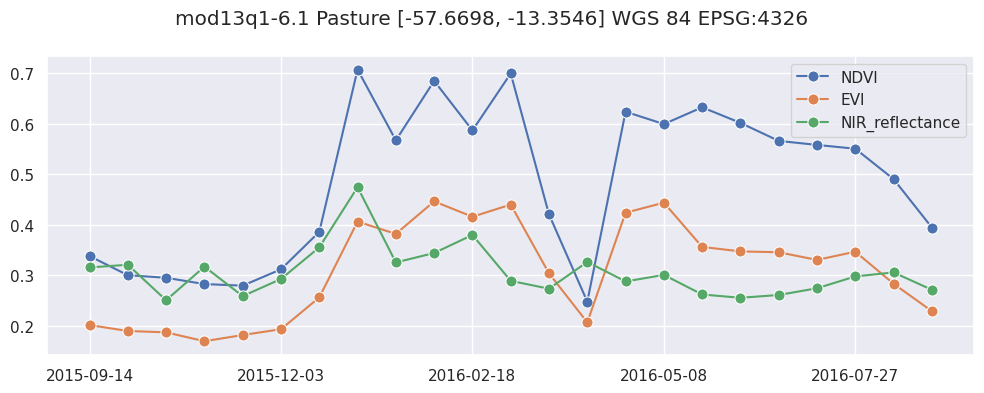

In [79]:
samples_norm = normalize_(samples, bands_description)
plot_ts(samples_norm, selection)

## Interpolação linear de valores nulos usando a variável _missing data_ nos metadados do satélite

In [5]:
samples_inter = interpolate_(samples_norm, bands_description)
samples_inter

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


## Suavização Savitzky Golay para generalizar os padrões

In [6]:
sgolay = SGolay(7, 3)
samples_smoothed = smooth_(samples_inter, sgolay)
samples_smoothed

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


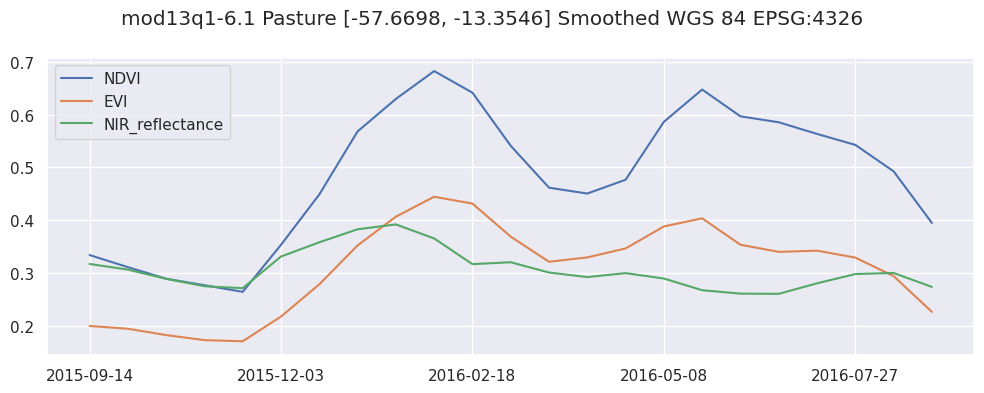

In [80]:
plot_ts(samples_smoothed, selection, marker = False, smoothed=True)

## Verificação simples para ver que as séries estão com os mesmo número de time stamps (observações)

In [8]:
def count_ts(samples):
    samples_ = samples.copy()
    count = []
    for row in range(0, len(samples_)):
        count.append(len(json.loads(samples_['time_series'][0])['Index']))
    return count

set(count_ts(samples_smoothed))

{23}

## Análise Exploratória - Visualização dos padrões de cada classe

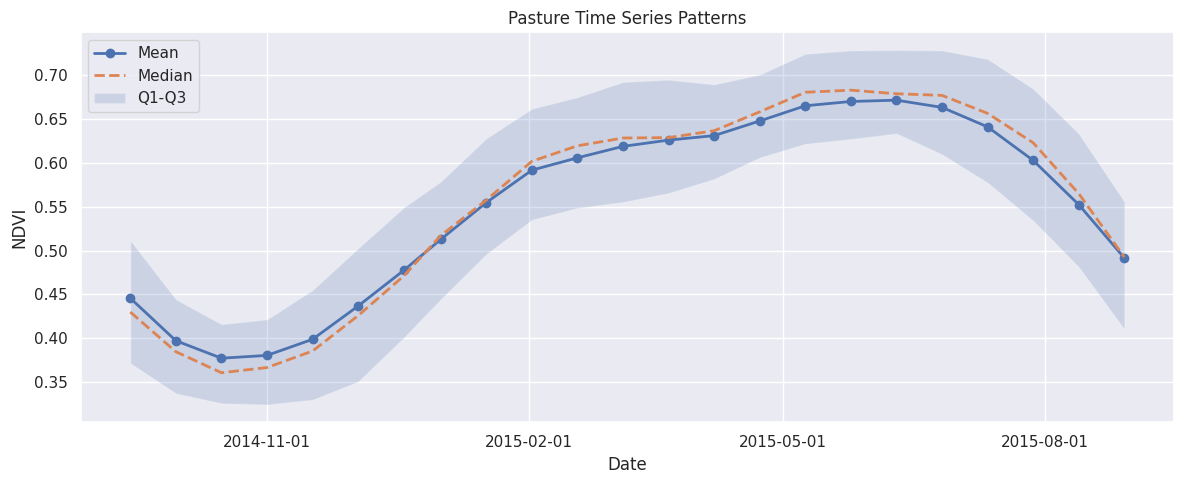

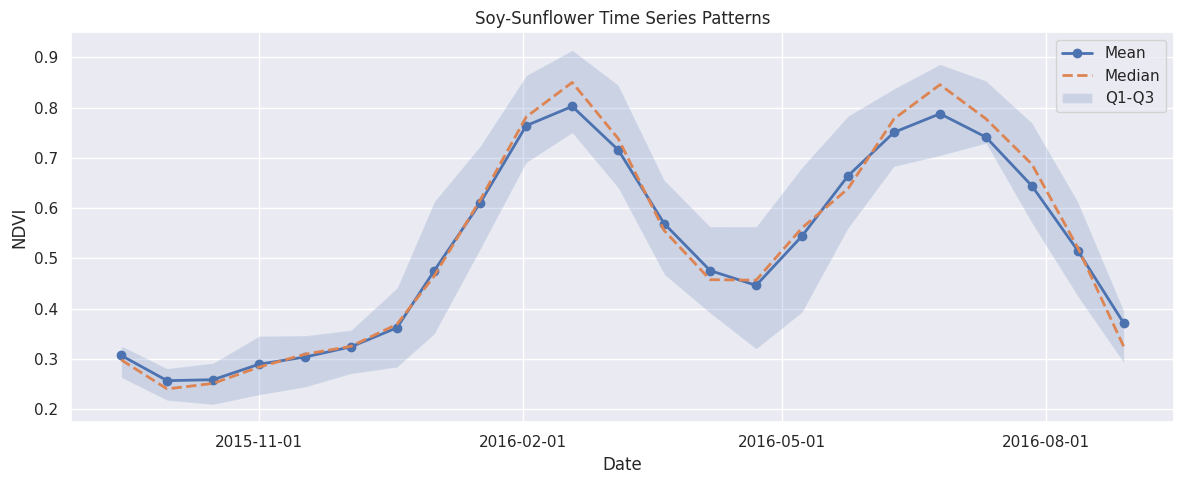

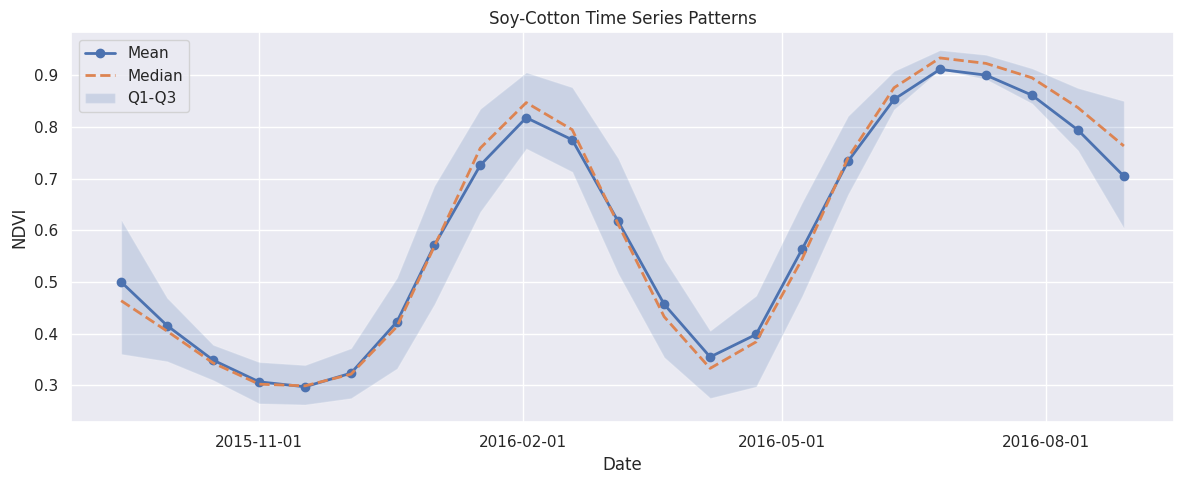

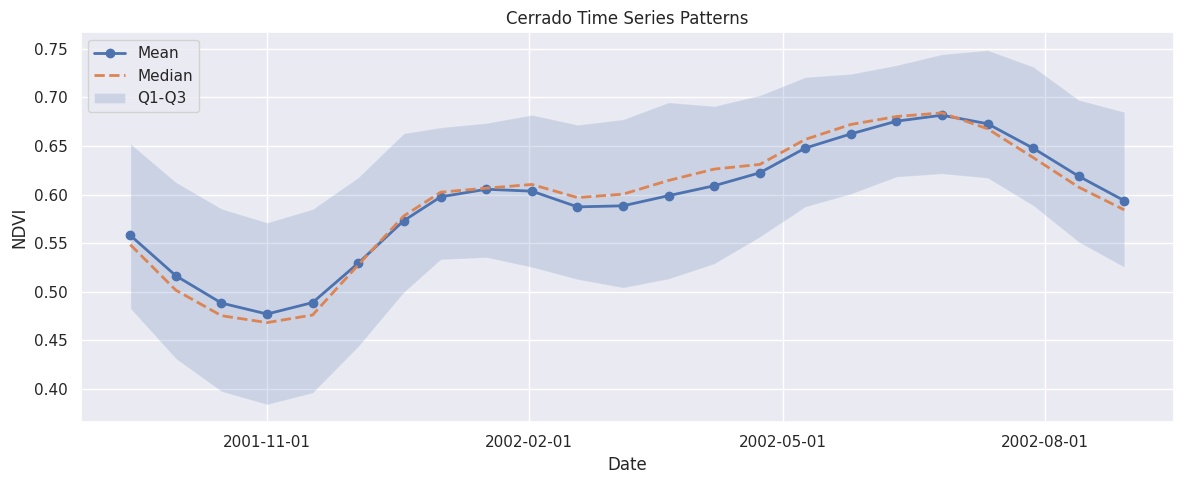

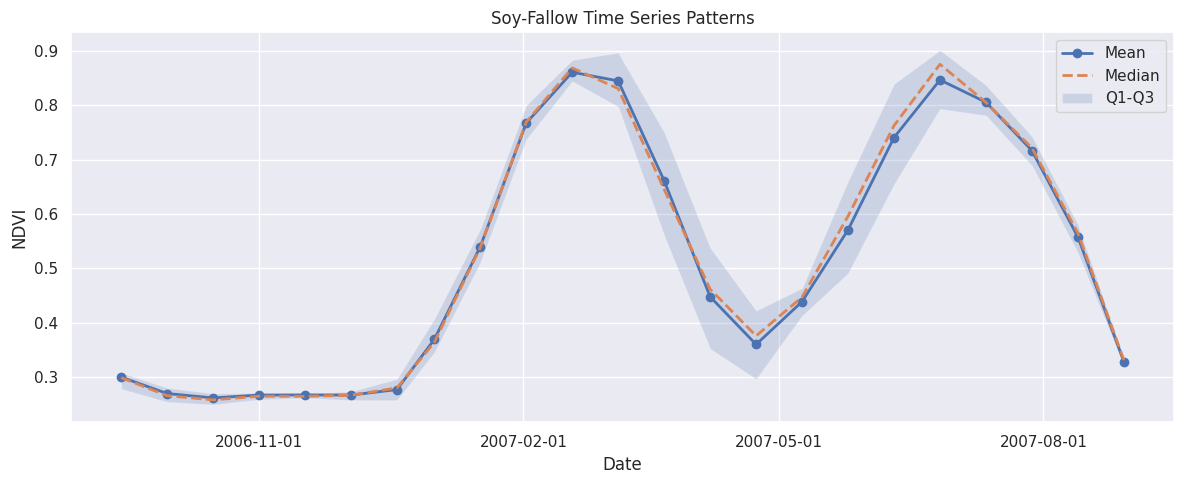

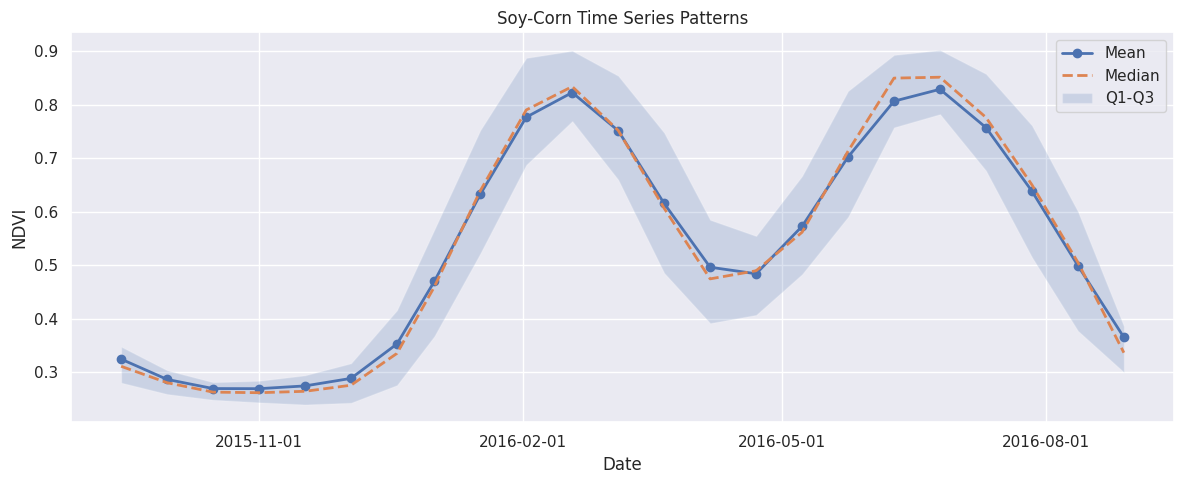

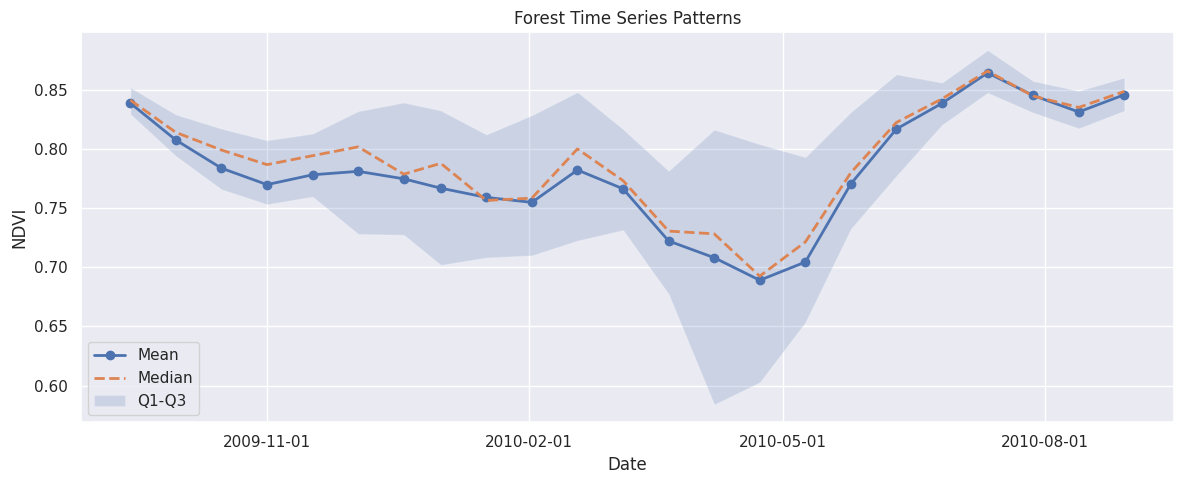

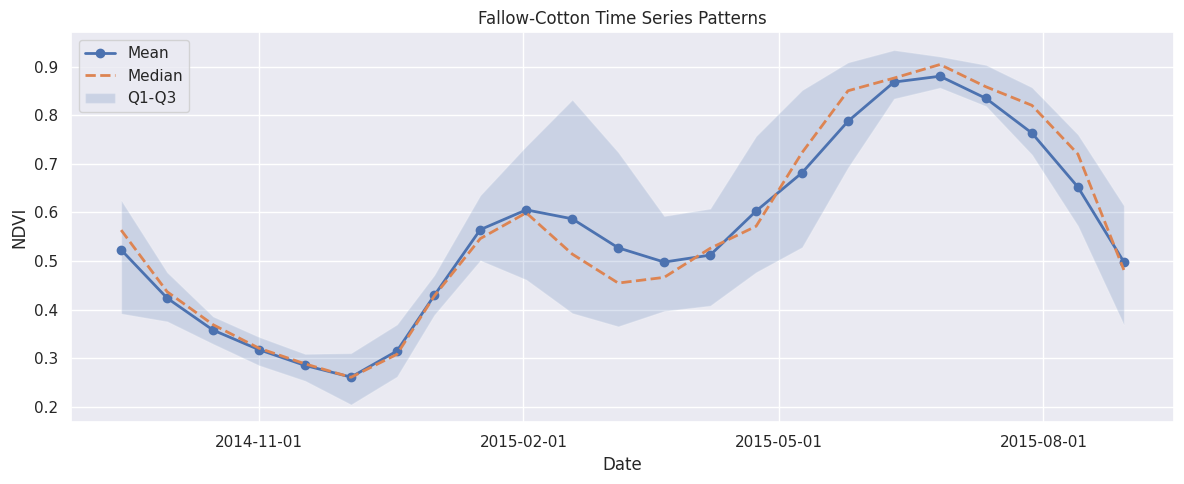

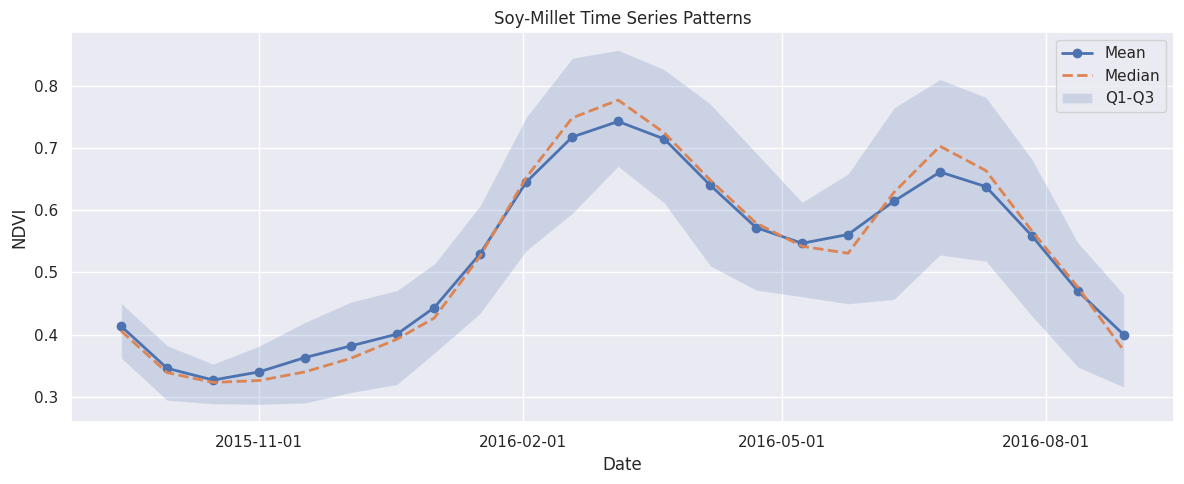

In [9]:
def plot_patterns(samples, band, step=3):

    labels = set(samples['label'])

    for label in labels:

        samples_label = (
            samples[samples['label'] == label]['time_series']
            .reset_index(drop=True)
        )

        all_values = []

        # Read all samples
        for row in range(len(samples_label)):

            df = pd.DataFrame(json.loads(samples_label[row]))

            # Keep only selected band
            values = df[band]

            all_values.append(values)

        # Create matrix:
        # rows = samples
        # cols = timesteps
        only_values = pd.concat(all_values, axis=1).T

        # Statistics
        mean_values = only_values.mean(axis=0)
        median_values = only_values.median(axis=0)

        q1 = only_values.quantile(0.25, axis=0)
        q3 = only_values.quantile(0.75, axis=0)

        # Dates
        indexes = pd.to_datetime(df["Index"])

        # Plot
        fig, ax = plt.subplots(figsize=(12, 5))

        # Mean curve
        ax.plot(
            indexes,
            mean_values,
            marker="o",
            linewidth=2,
            label="Mean"
        )

        # Median curve
        ax.plot(
            indexes,
            median_values,
            linestyle="--",
            linewidth=2,
            label="Median"
        )

        # Quartile interval
        ax.fill_between(
            indexes,
            q1,
            q3,
            alpha=0.2,
            label="Q1-Q3"
        )

        # Labels
        ax.set_title(f"{label} Time Series Patterns")
        ax.set_xlabel("Date")
        ax.set_ylabel(band)

        # Date spacing like your example
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=step))
        ax.xaxis.set_major_formatter(
            mdates.DateFormatter('%Y-%m-%d')
        )

        ax.legend()

        plt.tight_layout()
        plt.show()

plot_patterns(samples_smoothed, "NDVI")

## Definição do sistema de classificação

In [10]:
classes = np.unique(samples['label'])
getAllClasses(samples)

,class_name,index,color
0,Cerrado,0,#FF7D66
1,Fallow-Cotton,1,#5480FF
2,Forest,2,#BDBDBD
3,Pasture,3,#698891
4,Soy-Corn,4,#487D5D
5,Soy-Cotton,5,#AB5B96
6,Soy-Fallow,6,#45A2BF
7,Soy-Millet,7,#92D199
8,Soy-Sunflower,8,#92A7D1


## Balanço das classes

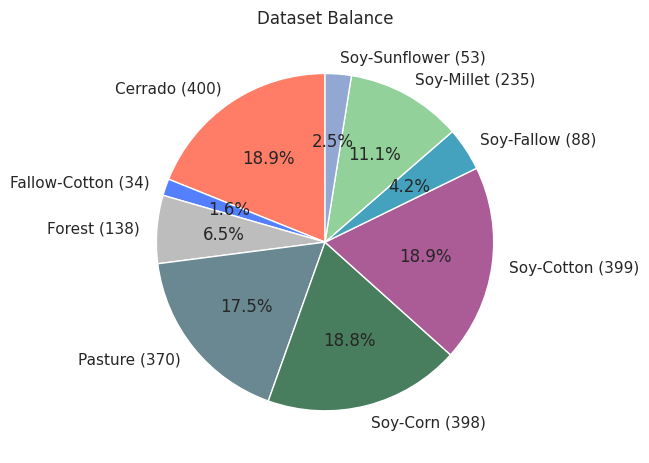

In [11]:
# Contar amostras por classe

def plot_distribution(samples):
    # ======================================================
    # CLASS COUNTS
    # ======================================================
    class_counts = pd.Series(samples['label']).value_counts().sort_index()
    # ======================================================
    # LABELS WITH COUNTS
    # ======================================================
    labels = []
    colors = []
    for label_ in class_counts.index:
        class_name = getClass(samples, label=label_)['class_name'][0]
        color = getClass(samples, label=label_)['color'][0]
        count = class_counts[label_]
        labels.append(f"{class_name} ({count})")
        colors.append(color)
    # ======================================================
    # PIE PLOT
    # ======================================================
    plt.figure()
    plt.pie(class_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Dataset Balance')
    plt.tight_layout()
    plt.show()

plot_distribution(samples = samples_smoothed)

## Formatando as séries temporais (_flatten_) para a MLP

In [88]:
random_sample = random.randint(0, (len(samples_smoothed) - 1))

original = samples_smoothed['time_series'][random_sample]
flatten = extract_features(original)

label = samples_smoothed['label'][random_sample]
label_code = encode_label(samples, label)
one_hot_ = one_hot_ = one_hot([label_code], len(list(set(y))))

print(f"Original => ({label}): ", original, "\n")
print(f"Flatten => ({label_code}) => ({one_hot_}): ", flatten)
print()

Original => (Pasture):  {"Index": ["2013-09-14", "2013-09-30", "2013-10-16", "2013-11-01", "2013-11-17", "2013-12-03", "2013-12-19", "2014-01-01", "2014-01-17", "2014-02-02", "2014-02-18", "2014-03-06", "2014-03-22", "2014-04-07", "2014-04-23", "2014-05-09", "2014-05-25", "2014-06-10", "2014-06-26", "2014-07-12", "2014-07-28", "2014-08-13", "2014-08-29"], "NDVI": [0.3880523809523808, 0.341119047619048, 0.33208333333333384, 0.34272857142857166, 0.3296238095238098, 0.34147142857142887, 0.34745714285714313, 0.4093476190476194, 0.5134333333333337, 0.6570857142857147, 0.7278000000000006, 0.7457095238095244, 0.7078333333333339, 0.7078000000000007, 0.720780952380953, 0.7368952380952387, 0.7358476190476197, 0.712033333333334, 0.6946000000000006, 0.6924047619047624, 0.6749166666666672, 0.6349309523809528, 0.5620809523809528], "EVI": [0.20722380952380942, 0.19440476190476202, 0.19471190476190497, 0.20102857142857158, 0.19138095238095254, 0.20371904761904777, 0.20382857142857158, 0.24903333333333

## Separação de treino, teste e validação usando _Holdout_

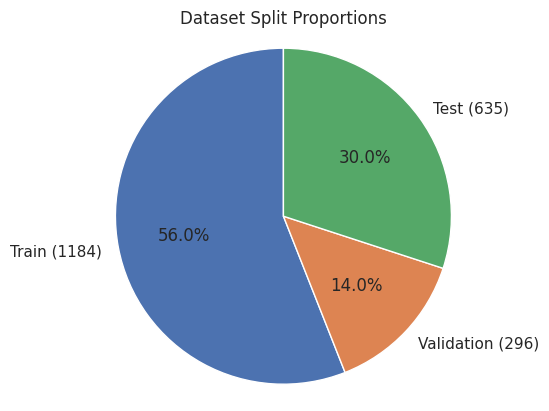

In [13]:
dataset = samples_smoothed.copy()

X = []
y = []

for _, row in dataset.iterrows():
    X.append(extract_features(row["time_series"]))
    y.append(encode_label(samples, row["label"]))

X = np.array(X)
y = np.array(y)

# Example usage with your variables
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train = (X_train - X_train.mean(axis=0)) / std_(X_train)
X_val = (X_val - X_val.mean(axis=0)) / std_(X_val)
X_test = (X_test - X_test.mean(axis=0)) / std_(X_test)

# Quantidade de amostras
train_size = len(X_train)
val_size = len(X_val)
test_size = len(X_test)

sizes = [train_size, val_size, test_size]
labels = [
    f"Train ({train_size})",
    f"Validation ({val_size})",
    f"Test ({test_size})"
]
plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Dataset Split Proportions")
plt.axis('equal')
plt.show()

## Arquitetura MLP

Usando regularização L2 para penalizar pesos grandes;

Usando early_stop;

Inicialização dos pesos com _He_;

Epoch 0 | Train Loss: 1.765738 | Val Loss: 1.201389

Early stopping at epoch 43
Best validation loss: 0.407923


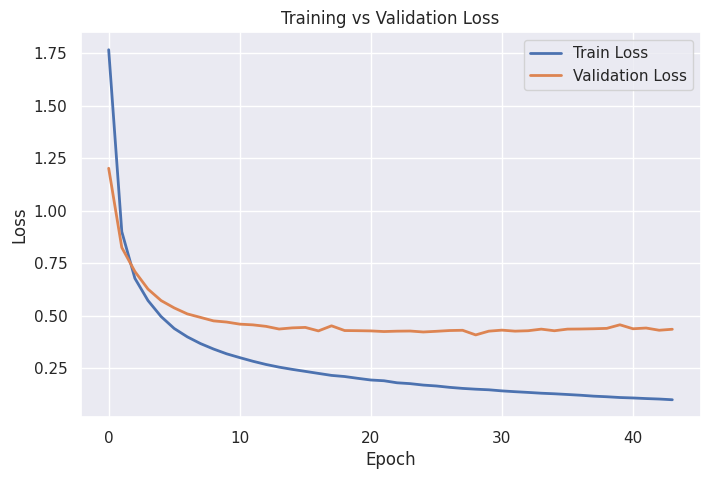

In [14]:
input_size = X.shape[1]

seed = 42

topology = [input_size, 32, 16, 9]

layers = [
    Layer(32, Neuron, relu, d_relu),
    Layer(16, Neuron, relu, d_relu),
    Layer(9, Neuron, softmax, d_softmax, multiclass=True)
]

nn = FFNeuralNetwork(topology, layers, method_init=He_, multiclass = True, lambda_l2=1e-4, rand_seed = seed)

nn.fit_with_validation(X_train, y_train, X_val, y_val, learning_rate=0.001, n_epochs=200, patience = 15)
nn.plot_train_val_loss()

## Arquitetura MLP usando os parâmetros pelo _Best Trial_

Epoch 0 | Train Loss: 0.234227 | Val Loss: 0.506425

Early stopping at epoch 20
Best validation loss: 0.368768


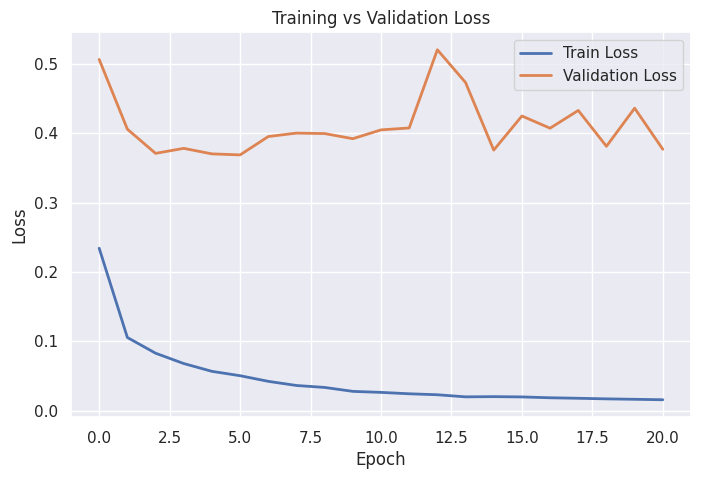

In [58]:
# Trial 16
# {'hidden1': 115, 'hidden2': 46, 'learning_rate': 0.008884237205192994, 'l2_lambda': 0.002587729914242751, 'activation': 'relu', 'initializer': 'he'}
# Elapsed time: 2828.104090 seconds

input_size = X.shape[1]

seed = 42

topology = [input_size, 115, 46, 9]

layers = [
    Layer(115, Neuron, relu, d_relu),
    Layer(46, Neuron, relu, d_relu),
    Layer(9, Neuron, softmax, d_softmax, multiclass=True)
]

nn_optuna = FFNeuralNetwork(topology, layers, method_init=He_, multiclass = True, lambda_l2=0.002587729914242751, rand_seed = seed)

nn_optuna.fit_with_validation(X_train, y_train, X_val, y_val, learning_rate=0.008884237205192994, n_epochs=200, patience = 15)
nn_optuna.plot_train_val_loss()

## Aplicação ao conjunto de teste

{'accuracy': 0.9007874015748032, 'precision': 0.891558592143118, 'recall': 0.8338329774647358, 'f1_score': 0.8498601674336566}


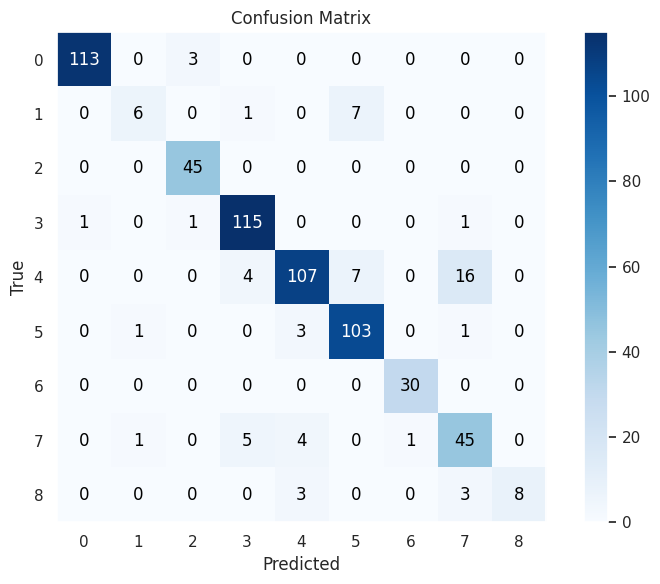

In [16]:
test_results = nn.test(X_test, y_test, threshold=0.7)

print(test_results["metrics"])

# predictions
y_probs, y_preds = nn.predict(X_test)

# plot confusion matrix
nn.plot_confusion_matrix(y_test, y_preds)

## Classificação de série temporal 2000 até 2026:

Usando uma janela deslizante de 23 timestamps.

Usando como base de validação o WLTS.

In [89]:
wlts_ = pd.read_csv("./samples/test_samples/wlts_ibge_mapbiomas_1.csv", sep = ";")
wtss_ = pd.read_csv("./samples/test_samples/wtss_mod13q1_1.csv")

def getAllClassesWLTS(wlts_):
    return pd.DataFrame({
        "class_name": list(set(wlts_["class"])),
        "index": [0, 1, 2],
        "color": ["#9BD3E8", "#C9C285", "#C0F279"]
    })

getAllClassesWLTS(wlts_)

,class_name,index,color
0,Algodão (beta),0,#9BD3E8
1,Área Agrícola,1,#C9C285
2,Soja,2,#C0F279


### Coordenada 1 POINT (-13.488908709549326 -57.962728754968744)

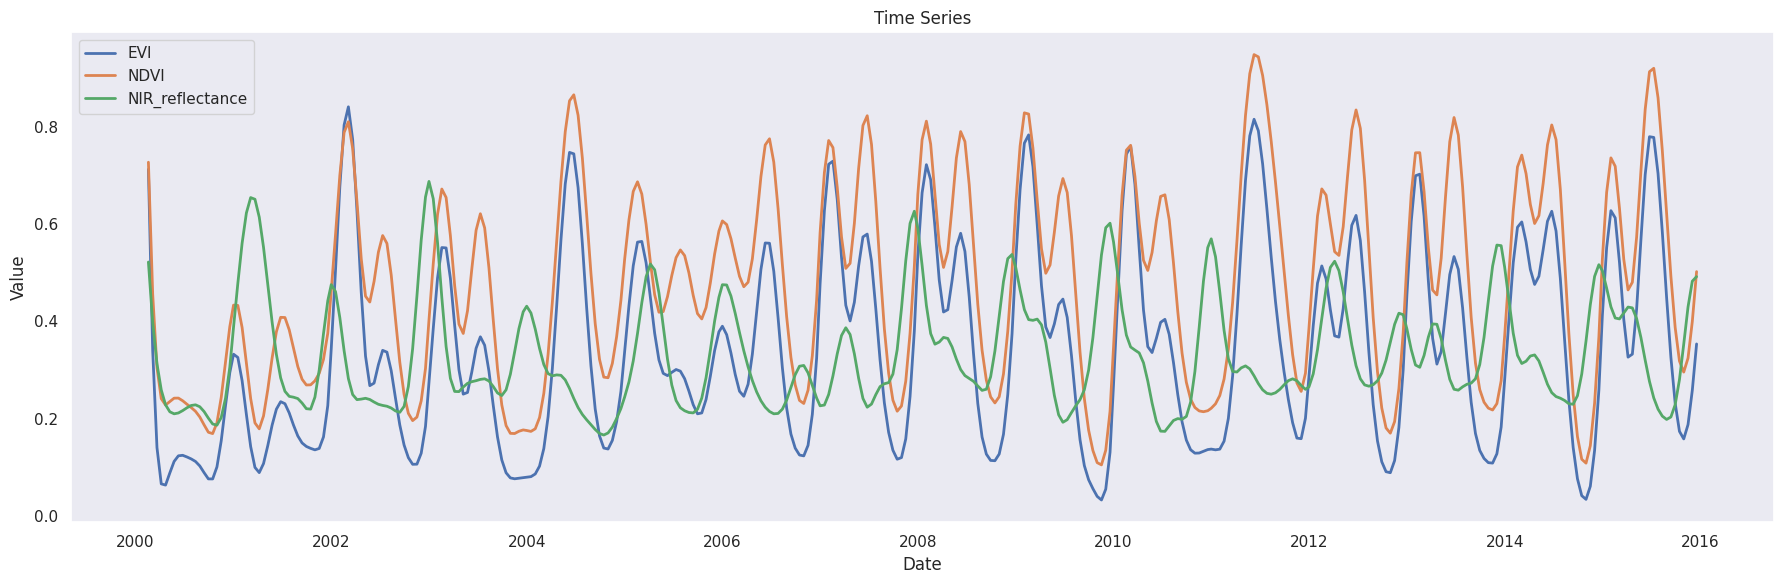

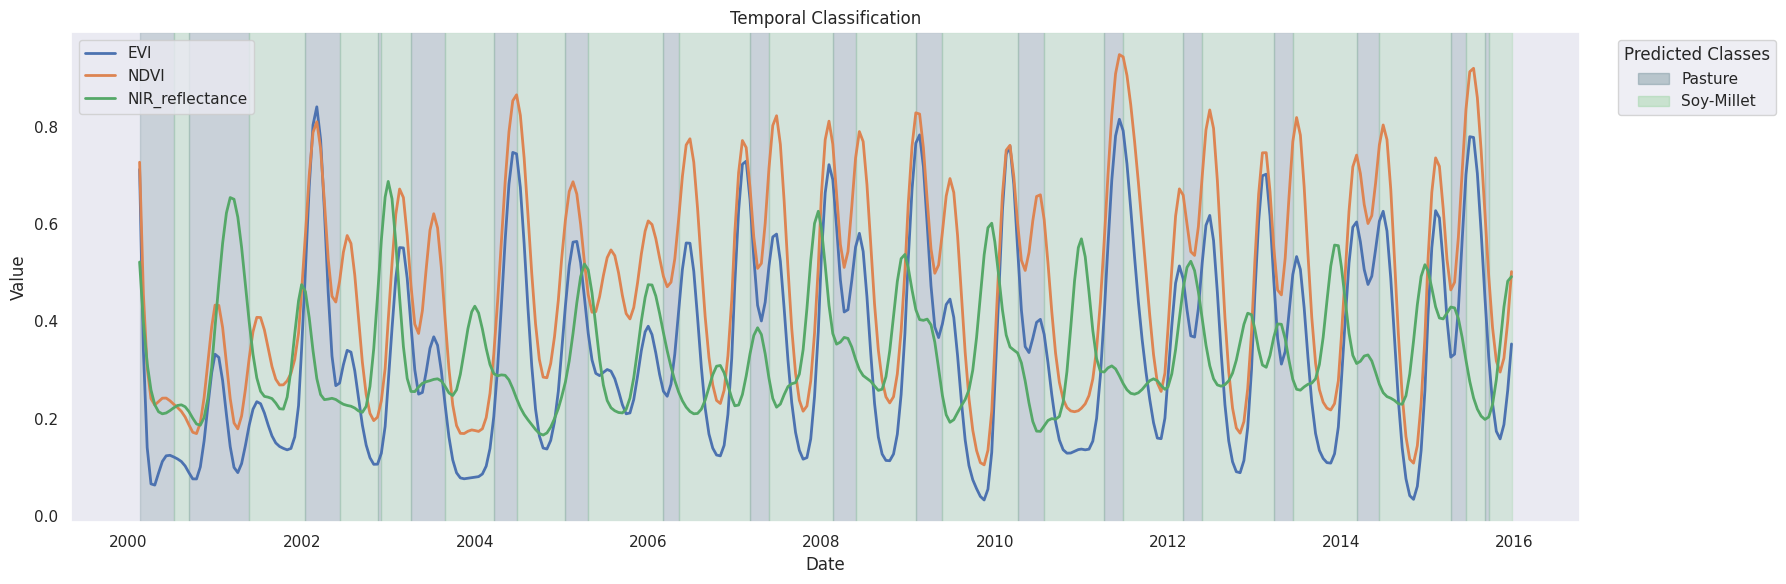

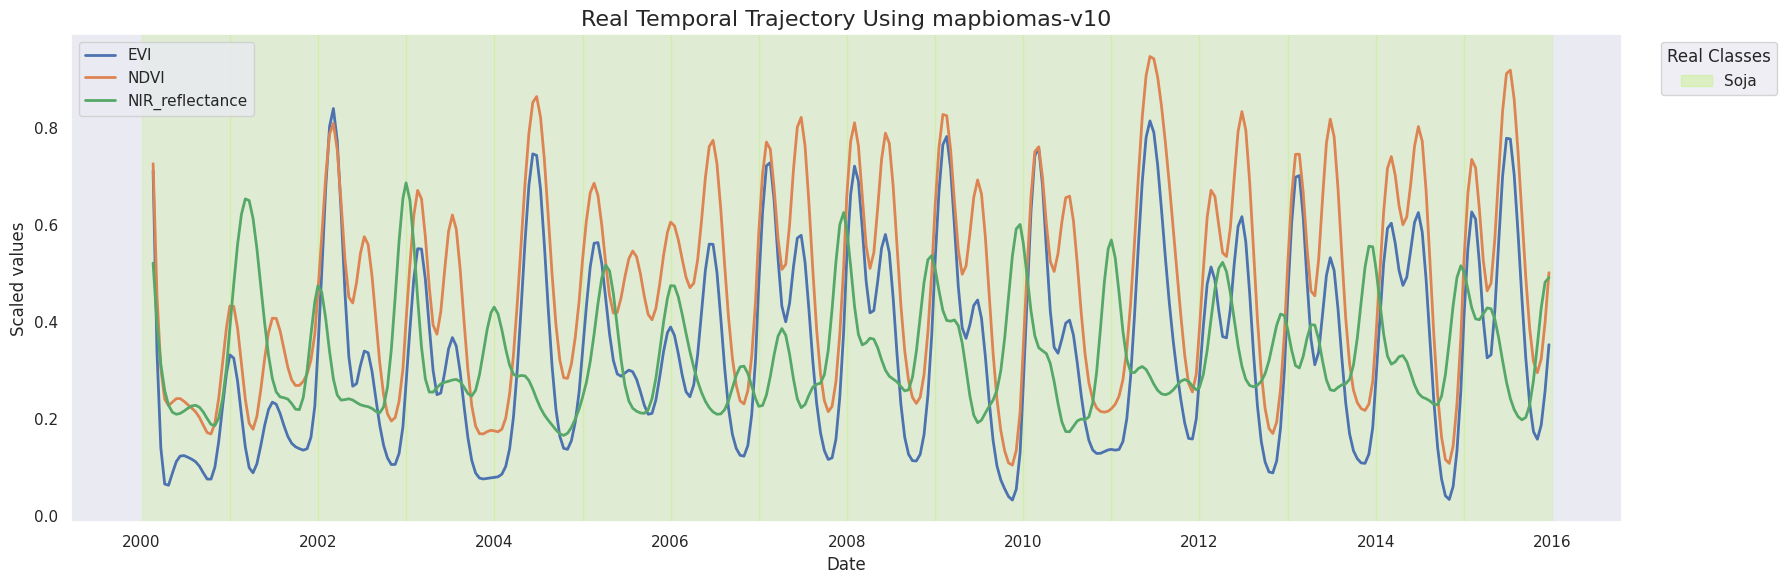

In [56]:
wtss_ = interpolate_single_ts(wtss_, bands_description)
wtss_ = sgolay.apply_ts(wtss_)
result, y_probs = classify_temporal_series(wtss_, nn, 23, stride = 1, thres = 0.6, class_system = getAllClasses(samples))

start_date_ = "2000-01-01"
end_date_ = "2015-12-31"

plot_temporal(
    wtss_,
    start_date=start_date_,
    end_date=end_date_
)
plot_temporal_classification(
    result,
    getAllClasses(samples),
    title="Temporal Classification",
    start_date=start_date_,
    end_date=end_date_
)
plot_real_trajectory(
    wtss_, wlts_,
    class_system=getAllClassesWLTS(wlts_),
    start_date=start_date_,
    end_date=end_date_
)

### Coordenada 2 POINT (-57.593558048109443 -13.742879971748621)

In [23]:
wlts_2 = pd.read_csv("./samples/test_samples/wlts_ibge_mapbiomas_2.csv", sep = ";")
wtss_2 = pd.read_csv("./samples/test_samples/wtss_mod13q1_2.csv")

def getAllClassesWLTS_2(wlts_2):
    return pd.DataFrame({
        "class_name": list(set(wlts_2["class"])),
        "index": [0, 1, 2, 3, 4, 5],
        "color": ["#698891", "#408694", "#9BD3E8", "#75FFAA", "#79FF1A", "#C0F279"]
    })

getAllClassesWLTS_2(wlts_2)

,class_name,index,color
0,Outras Lavouras Temporárias,0,#698891
1,Pastagem,1,#408694
2,Área Agrícola,2,#9BD3E8
3,Pastagem com Manejo,3,#75FFAA
4,Mosaico de Usos,4,#79FF1A
5,Soja,5,#C0F279


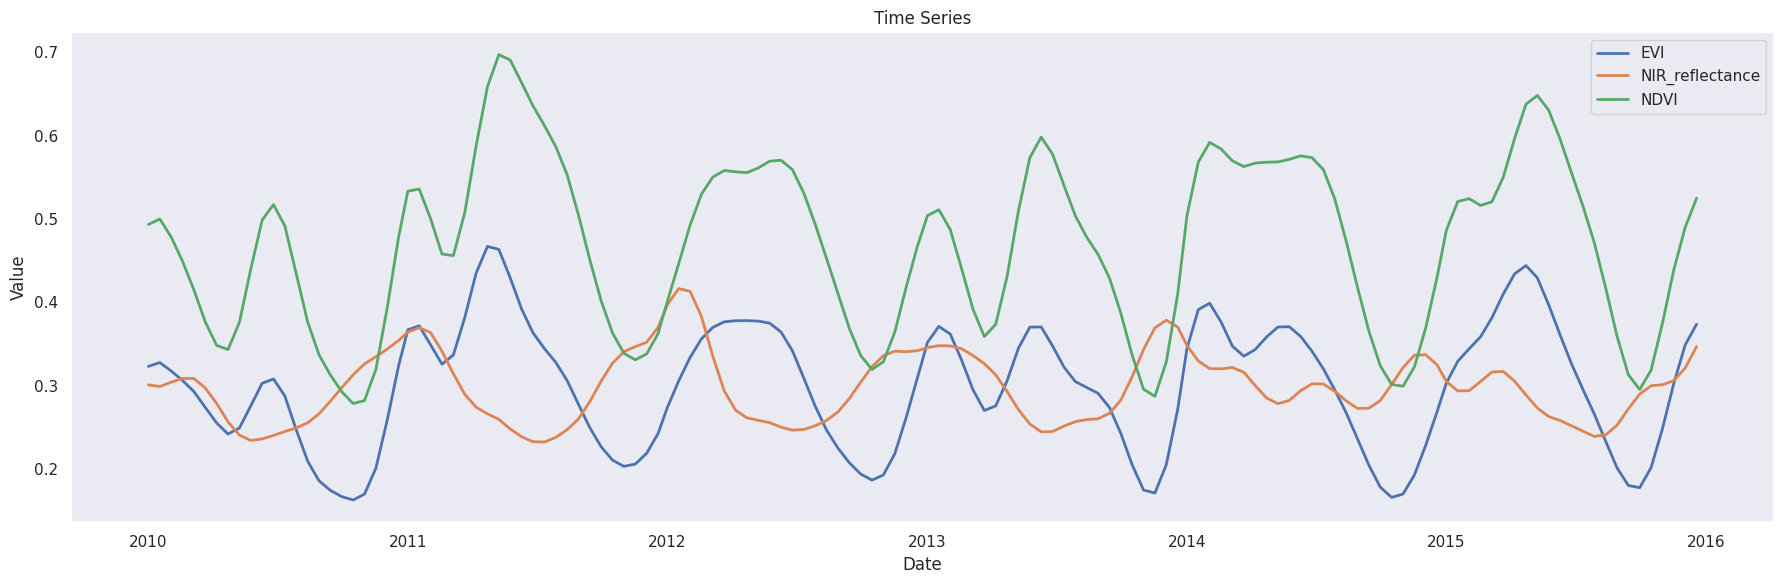

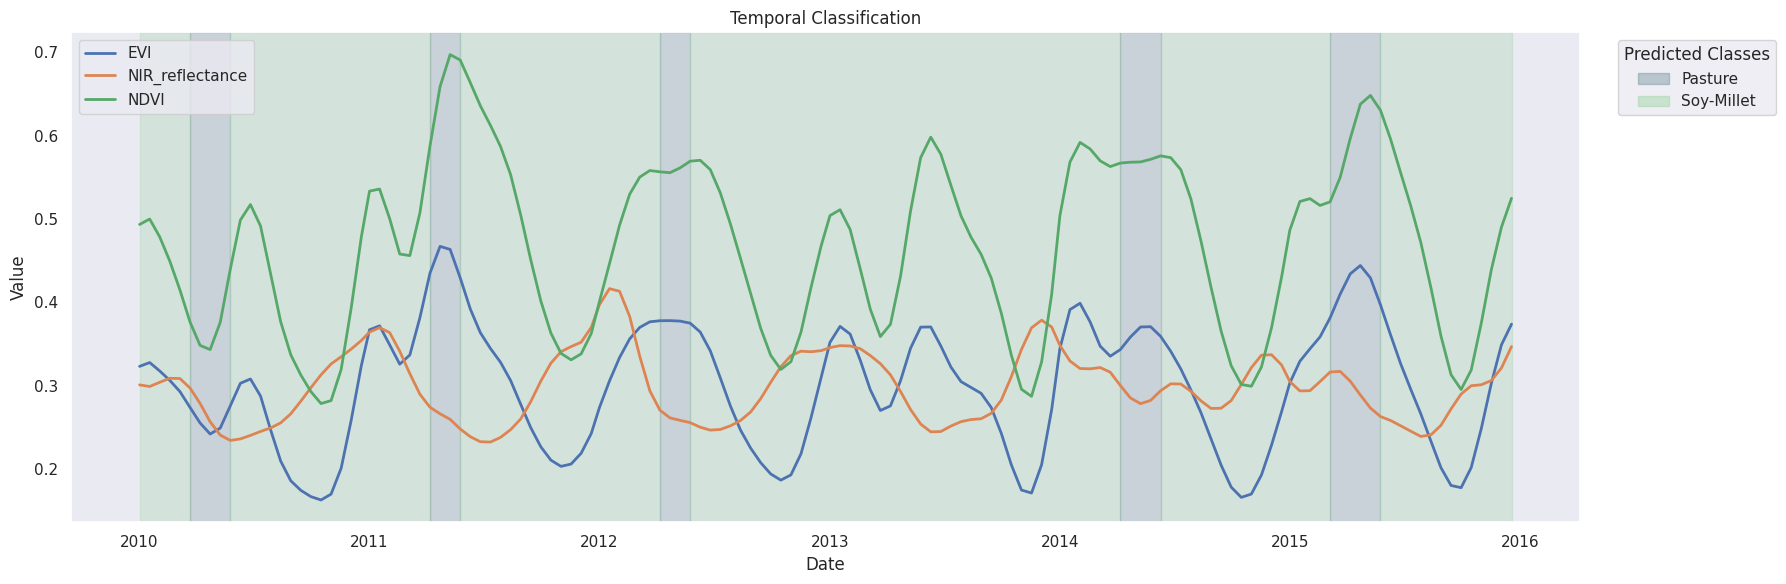

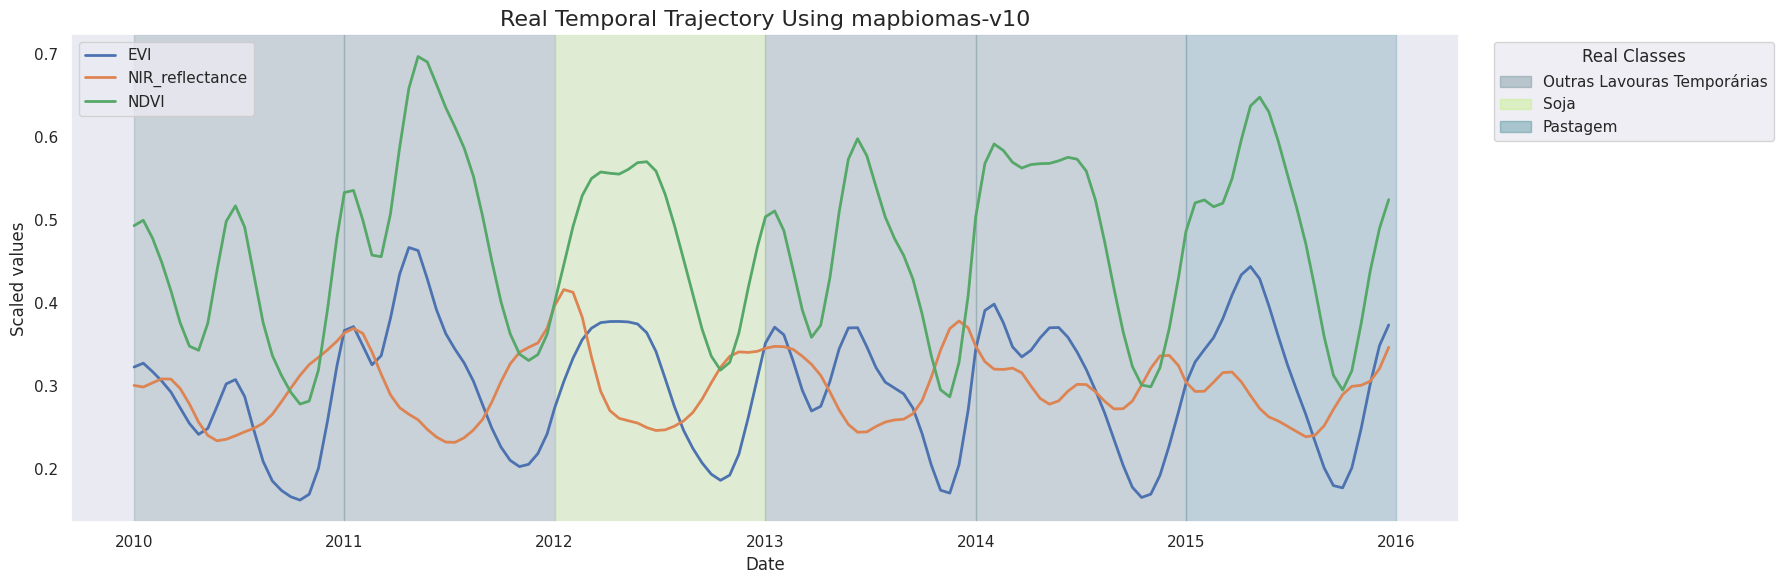

In [57]:
wtss_2 = interpolate_single_ts(wtss_2, bands_description)
wtss_2 = sgolay.apply_ts(wtss_2)
result, y_probs = classify_temporal_series(wtss_2, nn, 23, stride = 1, thres = 0.6, class_system = getAllClasses(samples))

start_date_ = "2010-01-01"
end_date_ = "2015-12-31"

plot_temporal(
    wtss_2,
    start_date=start_date_,
    end_date=end_date_
)
plot_temporal_classification(
    result,
    getAllClasses(samples),
    title="Temporal Classification",
    start_date=start_date_,
    end_date=end_date_
)
plot_real_trajectory(
    wtss_2, wlts_2,
    class_system=getAllClassesWLTS_2(wlts_2),
    start_date=start_date_,
    end_date=end_date_
)

### Coordenada 3 POINT (-57.593558048109443 -13.742879971748621)

In [26]:
wlts_3 = pd.read_csv("./samples/test_samples/wlts_ibge_mapbiomas_3.csv", sep = ";")
wtss_3 = pd.read_csv("./samples/test_samples/wtss_mod13q1_3.csv")

def getAllClassesWLTS_3(wlts_3):
    return pd.DataFrame({
        "class_name": list(set(wlts_3["class"])),
        "index": [0, 2, 3],
        "color": ["#9BD3E8", "#5480FF", "#C0F279"]
    })

getAllClassesWLTS_3(wlts_3)

,class_name,index,color
0,Algodão (beta),0,#9BD3E8
1,Área Agrícola,2,#5480FF
2,Soja,3,#C0F279


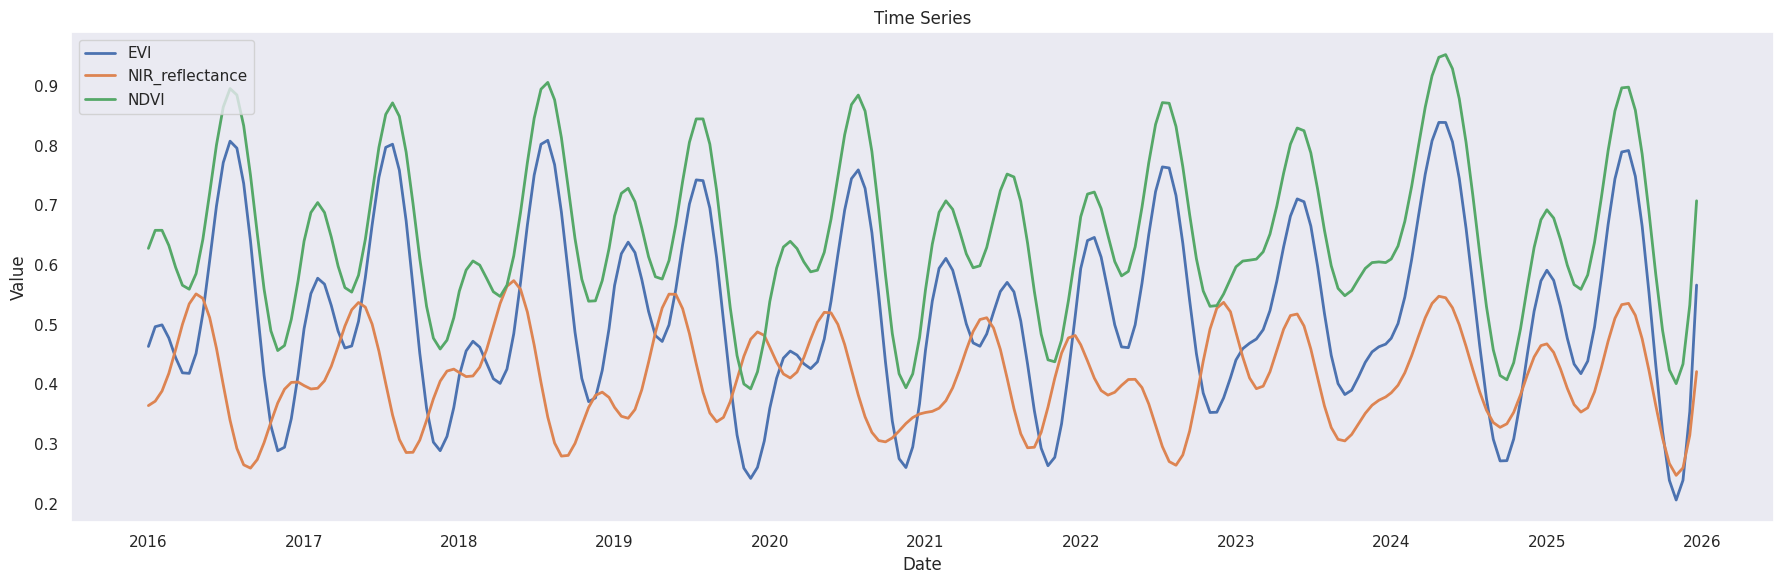

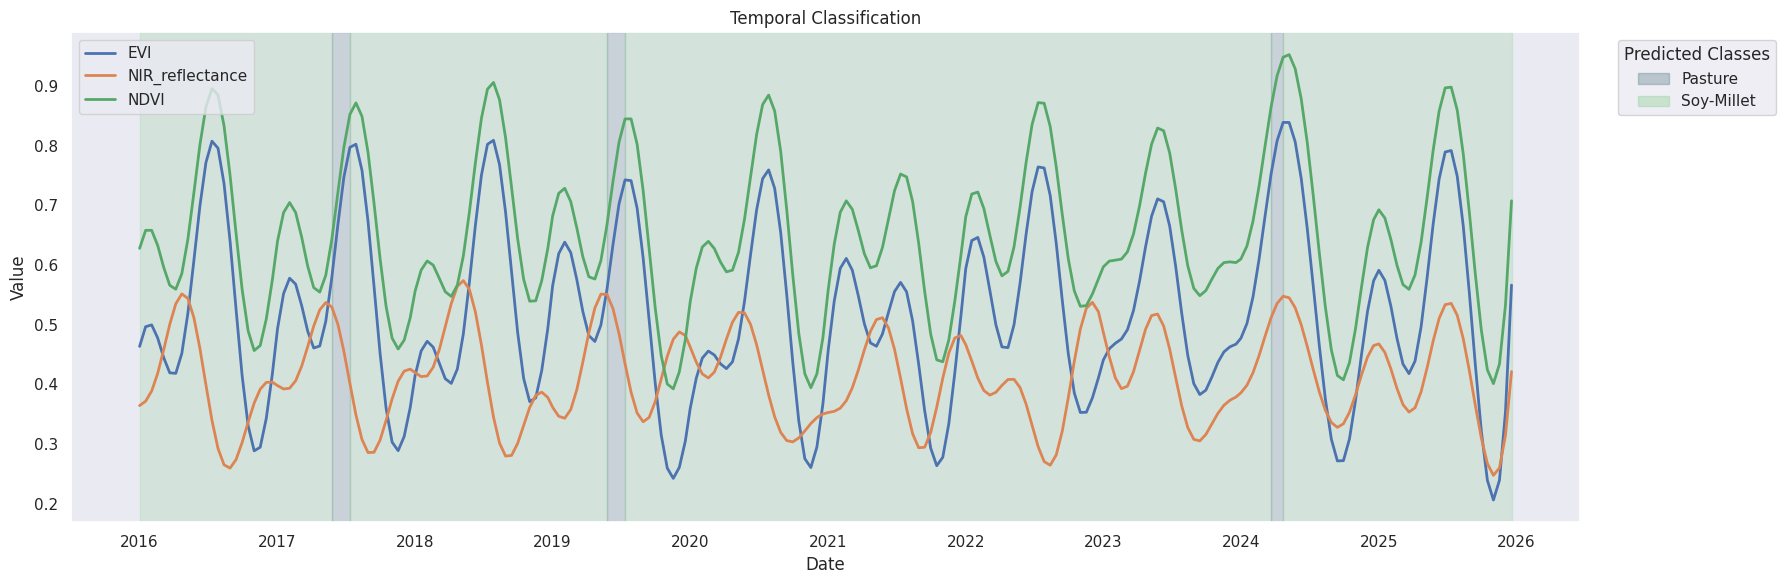

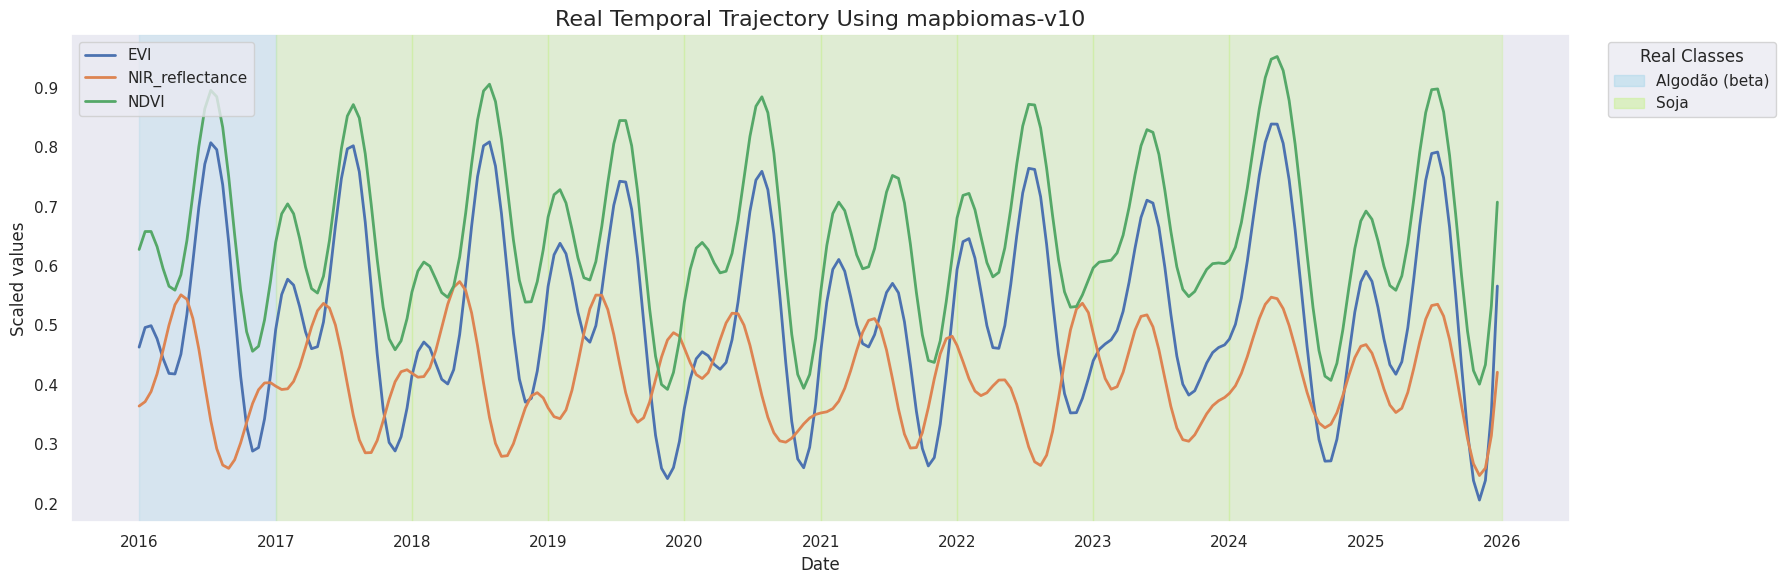

In [55]:
wtss_3 = interpolate_single_ts(wtss_3, bands_description)
wtss_3 = sgolay.apply_ts(wtss_3)
result, y_probs = classify_temporal_series(wtss_3, nn, 23, stride = 1, thres = 0.6, class_system = getAllClasses(samples))

start_date_ = "2016-01-01"
end_date_ = "2025-12-31"

plot_temporal(
    wtss_3,
    start_date=start_date_,
    end_date=end_date_
)
plot_temporal_classification(
    result,
    getAllClasses(samples),
    title="Temporal Classification",
    start_date=start_date_,
    end_date=end_date_
)
plot_real_trajectory(
    wtss_3, wlts_3,
    class_system=getAllClassesWLTS_3(wlts_3),
    collection="mapbiomas-v10",
    start_date=start_date_,
    end_date=end_date_
)